# Heart Disease Experiment

## kfc-procedure: A Unified Framework for Clusterwise Learning and COBRA-Based Ensemble Aggregation

This notebook presents a complete, reproducible, and academically rigorous classification experiment using the Heart Disease dataset.

The experiment evaluates three model groups:

1. **Baseline machine learning classifiers**
2. **COBRA-based aggregation** using `CombinedClassifier`
3. **KFCProcedure classification** using `KFCClassifier`

The notebook is designed as an experimental appendix and as supporting evidence for **Chapter 7: Experiments and Results** of the thesis.


## 1. Objective

### Purpose

The purpose of this experiment is to evaluate classification performance on the Heart Disease dataset using standard baseline classifiers, COBRA-based aggregation, and the KFCProcedure framework.

The experiment compares conventional supervised learning models against a hybrid procedure that combines divergence-based clustering, cluster-wise local learning, and prediction-space aggregation.

### Research Questions

This experiment addresses the following research questions:

1. How do standard machine learning classifiers perform on the Heart Disease classification task?
2. How does `CombinedClassifier` compare with individual baseline classifiers?
3. How does `KFCClassifier` compare with baseline classifiers and standalone COBRA-based aggregation?
4. Are the observed results stable across repeated train-test splits?

### Expected Evaluation

Since the task is classification, the experiment evaluates models using:

- Accuracy
- Precision
- Recall
- F1-score

The experiment uses repeated evaluation with the required random seeds:

```python
SEEDS = [42, 52, 62, 72, 82]
```

For each seed, the dataset is split, preprocessed, trained, predicted, and evaluated independently.


## 2. Dataset Description

### 2.1 Dataset Overview

The dataset used in this experiment is the Heart Disease dataset from Kaggle, as used in the repository notebook.

The repository notebook loads the dataset from:

```text
johnsmith88/heart-disease-dataset
```

The dataset file used by the notebook is:

```text
heart.csv
```

### 2.2 Feature Description

The observable feature columns in the repository notebook are:

- `age`
- `sex`
- `cp`
- `trestbps`
- `chol`
- `fbs`
- `restecg`
- `thalach`
- `exang`
- `oldpeak`
- `slope`
- `ca`
- `thal`

The dataset uses numerical or numerically encoded clinical variables. Additional clinical interpretation beyond the column names is **not observable from the provided materials**.

### 2.3 Target Variable

The target column is:

```text
target
```

All other columns are used as input features.


## 3. Exploratory Data Analysis (EDA)

The EDA section follows the dataset and repository-supported workflow:

1. Dataset shape
2. Data types
3. Missing value analysis
4. Duplicate analysis
5. Target distribution
6. Feature statistics
7. Correlation analysis
8. Additional visualizations

The repository notebook checks missing values using `df.isnull().sum()`, checks duplicates using `df.duplicated().sum()`, removes duplicates using `df.drop_duplicates()`, visualizes the target distribution, and visualizes the correlation matrix.

A formal outlier-removal procedure is **not observable from the provided materials**. Therefore, no outlier filtering is applied.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import sys
import time
import platform
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

OUTPUT_DIR = Path("outputs")
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)


### Repository Import Configuration

This notebook uses repository modules directly:

- `CombinedClassifier`
- `KFCClassifier`

The import cell first attempts to import the package from the active Python environment. If that fails, it searches upward for a local repository structure containing `src/kfc_procedure`.


In [2]:
def find_repo_root(start_path=None):
    '''
    Locate the repository root containing src/kfc_procedure.
    '''
    if start_path is None:
        start_path = Path.cwd()
    else:
        start_path = Path(start_path)

    for candidate in [start_path] + list(start_path.parents):
        if (candidate / "src" / "kfc_procedure").exists():
            return candidate

    raise FileNotFoundError(
        "Could not locate repository root containing src/kfc_procedure. "
        "Run this notebook inside the kfc-procedure repository or install the package."
    )


try:
    from kfc_procedure.cobra.combined_classifier import CombinedClassifier
    from kfc_procedure.kfc import KFCClassifier
    print("Imported kfc_procedure from installed environment.")
except ImportError:
    repo_root = find_repo_root()
    sys.path.insert(0, str(repo_root / "src"))

    from kfc_procedure.cobra.combined_classifier import CombinedClassifier
    from kfc_procedure.kfc import KFCClassifier

    print(f"Imported kfc_procedure from source path: {repo_root / 'src'}")


Imported kfc_procedure from installed environment.


### 3.1 Dataset Loading

The dataset is loaded using the Kaggle dataset source used in the repository notebook.

A local CSV path may be supplied through `DATASET_CSV_PATH` for offline reproducibility. If no local path is supplied, the notebook downloads the public Kaggle dataset using `kagglehub`.


In [3]:
DATASET_CSV_PATH = None  # Example: "data/heart.csv"
KAGGLE_DATASET = "johnsmith88/heart-disease-dataset"
DATASET_FILENAME = "heart.csv"

if DATASET_CSV_PATH is not None:
    csv_path = Path(DATASET_CSV_PATH)
    if not csv_path.exists():
        raise FileNotFoundError(f"DATASET_CSV_PATH does not exist: {csv_path}")
else:
    try:
        from kagglehub import dataset_download
    except ImportError:
        %pip install kagglehub
        from kagglehub import dataset_download

    dataset_path = dataset_download(KAGGLE_DATASET)
    csv_path = Path(dataset_path) / DATASET_FILENAME

if not csv_path.exists():
    raise FileNotFoundError(f"Dataset file not found: {csv_path}")

df_raw = pd.read_csv(csv_path)

df_raw.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


### 3.2 Dataset Shape

The following cell reports the raw dataset shape before any cleaning operation.


In [4]:
print("Raw dataset shape:", df_raw.shape)
print("Number of rows:", df_raw.shape[0])
print("Number of columns:", df_raw.shape[1])


Raw dataset shape: (1025, 14)
Number of rows: 1025
Number of columns: 14


### 3.3 Data Types

The following table shows the data type of each column.


In [5]:
data_types_table = pd.DataFrame({
    "Feature": df_raw.columns,
    "Data Type": df_raw.dtypes.astype(str).values,
})

display(data_types_table)


,Feature,Data Type
0,age,int64
1,sex,int64
2,cp,int64
3,trestbps,int64
4,chol,int64
5,fbs,int64
6,restecg,int64
7,thalach,int64
8,exang,int64
9,oldpeak,float64


### 3.4 Missing Value Analysis

Missing values are checked using:

```python
df.isnull().sum()
```

The repository Heart Disease notebook observed no missing values in its executed output. No missing-value imputation strategy is defined in the provided materials.


In [6]:
missing_values_table = df_raw.isnull().sum().reset_index()
missing_values_table.columns = ["Feature", "Missing Values"]
missing_values_table["Missing Percentage"] = missing_values_table["Missing Values"] / len(df_raw) * 100

display(missing_values_table)

print("Total missing values:", int(df_raw.isnull().sum().sum()))


,Feature,Missing Values,Missing Percentage
0,age,0,0.0
1,sex,0,0.0
2,cp,0,0.0
3,trestbps,0,0.0
4,chol,0,0.0
5,fbs,0,0.0
6,restecg,0,0.0
7,thalach,0,0.0
8,exang,0,0.0
9,oldpeak,0,0.0


Total missing values: 0


### 3.5 Duplicate Analysis

Duplicate rows are checked using:

```python
df.duplicated().sum()
```

The repository Heart Disease notebook observed 723 duplicate rows in its executed output and removed duplicates using `df.drop_duplicates()`.


In [7]:
duplicate_count = int(df_raw.duplicated().sum())
duplicate_percentage = duplicate_count / len(df_raw) * 100

print("Duplicate rows:", duplicate_count)
print("Duplicate percentage:", round(duplicate_percentage, 4), "%")


Duplicate rows: 723
Duplicate percentage: 70.5366 %


### 3.6 Target Distribution

The target distribution is visualized after duplicate removal, following the repository notebook's cleaning sequence.


In [8]:
TARGET_COLUMN = "target"

if TARGET_COLUMN not in df_raw.columns:
    raise ValueError(f"Target column '{TARGET_COLUMN}' was not found in the dataset.")

df_eda = df_raw.drop_duplicates().copy()

target_distribution_table = (
    df_eda[TARGET_COLUMN]
    .value_counts()
    .sort_index()
    .reset_index()
)
target_distribution_table.columns = ["Target Class", "Count"]
target_distribution_table["Percentage"] = (
    target_distribution_table["Count"] / target_distribution_table["Count"].sum() * 100
)

display(target_distribution_table)


,Target Class,Count,Percentage
0,0,138,45.695364
1,1,164,54.304636


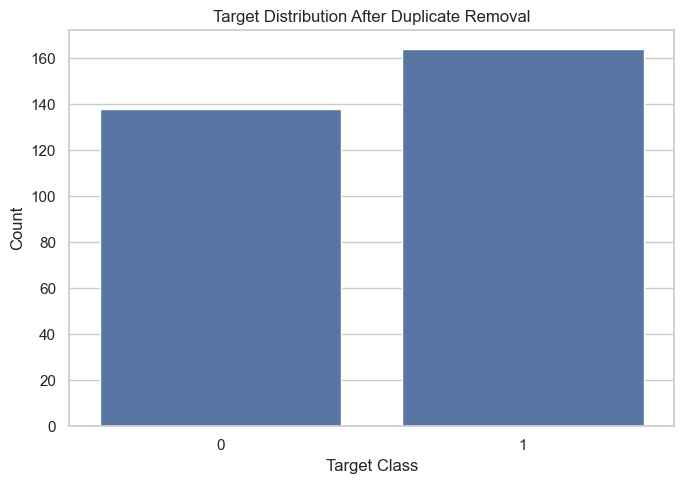

In [9]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df_eda, x=TARGET_COLUMN)
plt.title("Target Distribution After Duplicate Removal")
plt.xlabel("Target Class")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "heart_target_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


### 3.7 Feature Statistics

The following table reports descriptive statistics for the cleaned dataset after duplicate removal.


In [10]:
feature_statistics_table = df_eda.describe().T

display(feature_statistics_table)


,count,mean,std,min,25%,50%,75%,max
age,302.0,54.420530,9.047970,29.0,48.00,55.5,61.00,77.0
sex,302.0,0.682119,0.466426,0.0,0.00,1.0,1.00,1.0
cp,302.0,0.963576,1.032044,0.0,0.00,1.0,2.00,3.0
trestbps,302.0,131.602649,17.563394,94.0,120.00,130.0,140.00,200.0
chol,302.0,246.500000,51.753489,126.0,211.00,240.5,274.75,564.0
fbs,302.0,0.149007,0.356686,0.0,0.00,0.0,0.00,1.0
restecg,302.0,0.526490,0.526027,0.0,0.00,1.0,1.00,2.0
thalach,302.0,149.569536,22.903527,71.0,133.25,152.5,166.00,202.0
exang,302.0,0.327815,0.470196,0.0,0.00,0.0,1.00,1.0
oldpeak,302.0,1.043046,1.161452,0.0,0.00,0.8,1.60,6.2


### 3.8 Correlation Analysis

The repository notebook visualized the correlation matrix using a heatmap.


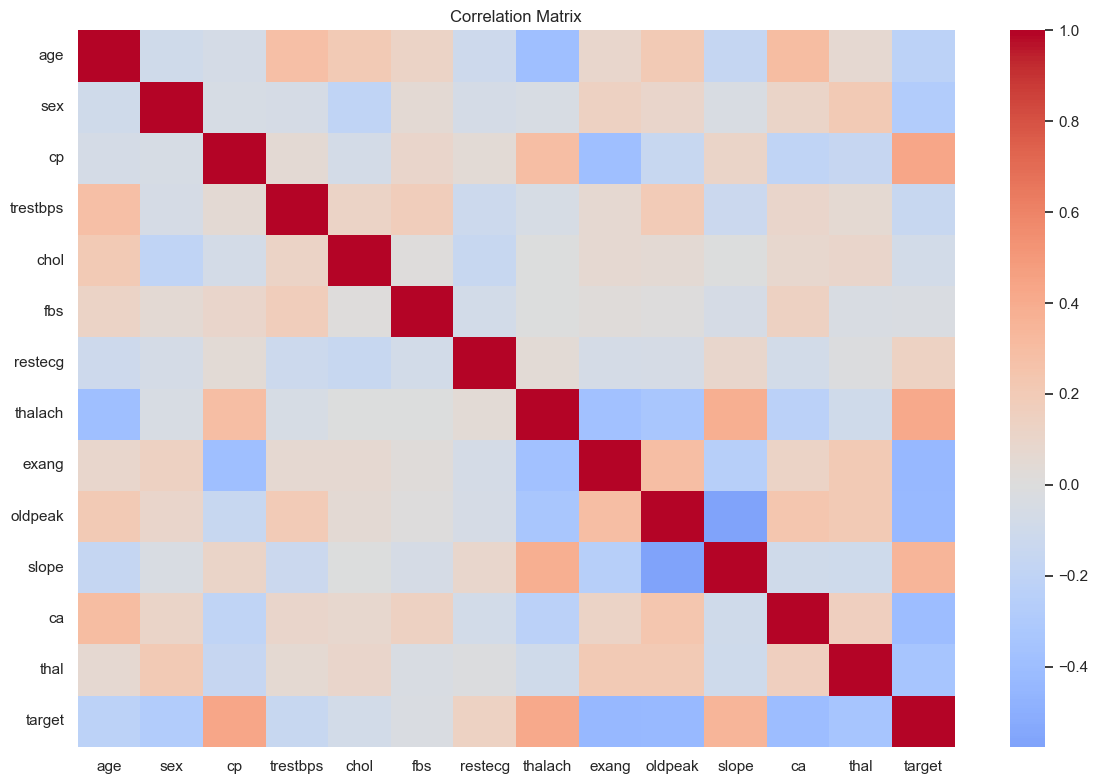

In [11]:
correlation_matrix = df_eda.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "heart_correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()


### 3.9 Additional Visualizations

The following visualization reports the absolute correlation between each feature and the target variable. This is used only for exploratory interpretation and is not used as a feature selection rule.


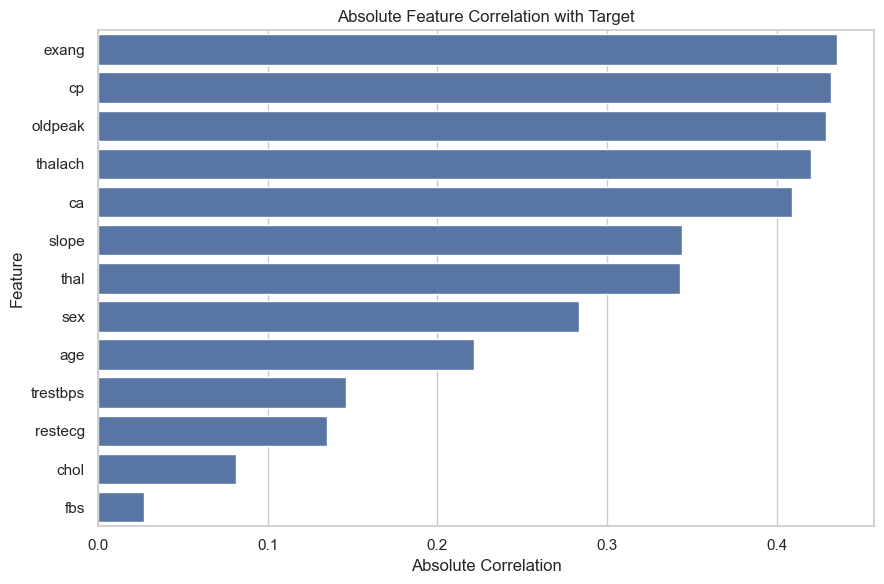

In [12]:
target_correlations = (
    correlation_matrix[TARGET_COLUMN]
    .drop(TARGET_COLUMN)
    .abs()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 6))
sns.barplot(x=target_correlations.values, y=target_correlations.index)
plt.title("Absolute Feature Correlation with Target")
plt.xlabel("Absolute Correlation")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "heart_target_correlation_bar.png", dpi=300, bbox_inches="tight")
plt.show()


## 4. Data Cleaning

### 4.1 Missing Value Handling

The repository notebook checks missing values using `df.isnull().sum()`. Since the executed notebook observed no missing values, no imputation is applied.

If missing values are observed in a different dataset version, the handling strategy is **not observable from the provided materials** and must be explicitly defined before model training.

### 4.2 Duplicate Removal

Duplicate rows are removed using:

```python
df = df.drop_duplicates()
```

This follows the repository Heart Disease notebook.

### 4.3 Outlier Inspection

A formal outlier inspection or removal strategy is **not observable from the provided materials**. Therefore, no outlier filtering is applied.

### 4.4 Data Consistency Checks

The notebook verifies that:

- the target column exists,
- the target has at least two classes,
- all model input columns are numeric,
- no duplicate rows remain after duplicate removal,
- there are no missing values under the repository-supported missing-value check.


In [13]:
df = df_raw.copy()

if TARGET_COLUMN not in df.columns:
    raise ValueError(f"Required target column '{TARGET_COLUMN}' is missing.")

if df.isnull().sum().sum() == 0:
    print("Missing value handling: no imputation applied because no missing values were found.")
else:
    raise ValueError(
        "Missing values were found, but imputation is not defined in the provided materials."
    )

rows_before = len(df)
df = df.drop_duplicates().copy()
rows_after = len(df)

print("Rows before duplicate removal:", rows_before)
print("Rows after duplicate removal:", rows_after)
print("Rows removed:", rows_before - rows_after)
print("Remaining duplicate rows:", int(df.duplicated().sum()))

if df[TARGET_COLUMN].nunique() < 2:
    raise ValueError("The target variable must contain at least two classes.")

non_numeric_columns = df.drop(columns=[TARGET_COLUMN]).select_dtypes(exclude=[np.number]).columns.tolist()
if non_numeric_columns:
    raise ValueError(f"Non-numeric feature columns found: {non_numeric_columns}")

print("Outlier removal: Not observable from the provided materials; no outlier filtering applied.")
print("Final cleaned dataset shape:", df.shape)
print("Target classes:", sorted(df[TARGET_COLUMN].unique()))


Missing value handling: no imputation applied because no missing values were found.
Rows before duplicate removal: 1025
Rows after duplicate removal: 302
Rows removed: 723
Remaining duplicate rows: 0
Outlier removal: Not observable from the provided materials; no outlier filtering applied.
Final cleaned dataset shape: (302, 14)
Target classes: [np.int64(0), np.int64(1)]


## 5. Data Preprocessing

### 5.1 Feature Encoding

Additional feature encoding is **not observable from the provided materials**. The dataset columns are already numerical or numerically encoded.

### 5.2 Feature Scaling

The repository Heart Disease notebook applies `MinMaxScaler(feature_range=(0.05, 0.95))` for the KFCClassifier experiment. This scaling keeps feature values positive, which is important for divergence-based clustering.

For fair model comparison in this controlled experiment, the same scaler is fitted on each seed-specific training split and applied to the corresponding test split before training all evaluated classifiers. This uses a repository-supported preprocessing method and prevents data leakage.

### 5.3 Feature Selection

Feature selection is **not observable from the provided materials**. Therefore, all columns except `target` are used as input features.

### 5.4 Final Feature Matrix

The feature matrix is:

```python
X = df.drop(columns=["target"])
```

The target vector is:

```python
y = df["target"]
```


In [14]:
X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN]

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)
print("Feature columns:")
print(X.columns.tolist())


Feature matrix shape: (302, 13)
Target vector shape: (302,)
Feature columns:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


## 6. Experimental Setup

### 6.1 Environment Configuration

The following cell records the execution environment for reproducibility.


In [15]:
environment_info = {
    "Python": platform.python_version(),
    "Platform": platform.platform(),
    "NumPy": np.__version__,
    "Pandas": pd.__version__,
    "Scikit-learn": sklearn.__version__,
}

environment_table = pd.DataFrame(environment_info.items(), columns=["Component", "Version"])

display(environment_table)


,Component,Version
0,Python,3.11.15
1,Platform,macOS-26.5.1-arm64-arm-64bit
2,NumPy,2.4.6
3,Pandas,3.0.3
4,Scikit-learn,1.9.0


### 6.2 Random Seed Configuration

The required repeated evaluation seeds are used exactly:

```python
SEEDS = [42, 52, 62, 72, 82]
```


In [16]:
SEEDS = [42, 52, 62, 72, 82]
TEST_SIZE = 0.2
SCALER_RANGE = (0.05, 0.95)
PRIMARY_METRIC = "Accuracy"

print("Seeds:", SEEDS)
print("Test size:", TEST_SIZE)
print("Scaler range:", SCALER_RANGE)
print("Primary ranking metric:", PRIMARY_METRIC)


Seeds: [42, 52, 62, 72, 82]
Test size: 0.2
Scaler range: (0.05, 0.95)
Primary ranking metric: Accuracy


### 6.3 Train-Test Split Strategy

For every seed, the dataset is split using:

```python
train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=seed,
)
```

The split is stratified on the target variable to preserve the class distribution in both training and testing sets.

### 6.4 Hyperparameter Configuration

The repository Heart Disease notebook evaluates the following baseline model families:

- Logistic Regression
- Random Forest Classifier
- SVC
- KNeighborsClassifier
- GaussianNB

The COBRA experiment uses:

- `CombinedClassifier`

The KFCProcedure experiment uses:

- `KFCClassifier`
- divergences: `['euclidean', 'gkl', 'is', 'logistic']`
- local model: `logistic_regression`
- combiner: `combined_classifier`
- number of clusters: `2`

A standalone Decision Tree baseline is not included because it is **not observable from the provided Heart Disease notebook** as a separately evaluated baseline.

`GradientCOBRA` and `MixCOBRARegressor` are not used because they are regression-oriented and not appropriate for this classification task.

### 6.5 Evaluation Protocol

For each seed:

1. Split the dataset.
2. Fit `MinMaxScaler(feature_range=(0.05, 0.95))` on the training split only.
3. Transform both training and testing features.
4. Train each baseline classifier.
5. Train `CombinedClassifier`.
6. Train `KFCClassifier`.
7. Predict on the same seed-specific test split.
8. Store all metrics in `all_results`.


## 7. Evaluation Metrics

The task is classification, so the following metrics are used.

Let:

- TP = true positives
- TN = true negatives
- FP = false positives
- FN = false negatives

### Accuracy

\[
Accuracy = \frac{TP + TN}{TP + TN + FP + FN}
\]

Scikit-learn implementation:

```python
accuracy_score(y_true, y_pred)
```

### Precision

\[
Precision = \frac{TP}{TP + FP}
\]

Scikit-learn implementation:

```python
precision_score(y_true, y_pred, average="weighted", zero_division=0)
```

### Recall

\[
Recall = \frac{TP}{TP + FN}
\]

Scikit-learn implementation:

```python
recall_score(y_true, y_pred, average="weighted", zero_division=0)
```

### F1-score

\[
F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}
\]

Scikit-learn implementation:

```python
f1_score(y_true, y_pred, average="weighted", zero_division=0)
```


In [17]:
def evaluate_classification(y_true, y_pred, average="weighted"):
    '''
    Evaluate classification predictions using the metrics required for this experiment.
    '''
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average=average, zero_division=0),
        "Recall": recall_score(y_true, y_pred, average=average, zero_division=0),
        "F1 Score": f1_score(y_true, y_pred, average=average, zero_division=0),
    }


## 8. Baseline Models

For each baseline classifier, the experiment performs:

1. Configuration
2. Training
3. Prediction
4. Evaluation

All baseline models are trained and evaluated on the same seed-specific train-test split.


In [18]:
BASELINE_ESTIMATOR_NAMES = [
    "logistic_regression",
    "random_forest_classifier",
    "svc",
    "k_neighbors_classifier",
    "gaussian_nb",
]


def make_baseline_models(seed):
    '''
    Create baseline sklearn classifiers for one seed-specific experiment run.

    The model families follow the repository Heart Disease notebook.
    '''
    return {
        "Logistic Regression": LogisticRegression(random_state=seed),
        "Random Forest Classifier": RandomForestClassifier(random_state=seed),
        "SVC": SVC(probability=True, random_state=seed),
        "KNeighborsClassifier": KNeighborsClassifier(),
        "GaussianNB": GaussianNB(),
    }


def make_combined_classifier(seed):
    '''
    Create the repository-supported COBRA classifier.
    '''
    return CombinedClassifier(
        estimators=BASELINE_ESTIMATOR_NAMES,
        estimators_params={
            "logistic_regression": {"random_state": seed},
            "random_forest_classifier": {"random_state": seed},
            "svc": {"probability": True, "random_state": seed},
            "k_neighbors_classifier": {},
            "gaussian_nb": {},
        },
        random_state=seed,
    )


def make_kfc_classifier(seed):
    '''
    Create the repository-supported KFCClassifier configuration for classification.

    K-Step:
        divergence-based clustering using euclidean, gkl, is, and logistic divergences

    F-Step:
        cluster-wise logistic regression local learner

    C-Step:
        combined_classifier aggregation
    '''
    return KFCClassifier(
        divergences=["euclidean", "gkl", "is", "logistic"],
        local_model="logistic_regression",
        combiner="combined_classifier",
        n_clusters=2,
        random_state=seed,
    )


## 9. COBRA Experiments

### Configuration

The classification-appropriate COBRA component used in this experiment is `CombinedClassifier`.

`CombinedClassifier` operates in prediction space by training base estimators, transforming observations into intermediate prediction vectors, computing similarity in that prediction space, and aggregating labels through a weighted voting mechanism.

### Training

For each seed, `CombinedClassifier` is trained on the same training split as the baseline models.

### Prediction

The trained `CombinedClassifier` predicts labels on the corresponding held-out test split.

### Evaluation

Predictions are evaluated with Accuracy, Precision, Recall, and F1-score.

### Excluded COBRA Models

The following repository COBRA models are not used in this classification experiment:

- `GradientCOBRA`: regression-oriented
- `MixCOBRARegressor`: regression-only

Their exclusion avoids applying regression models to a classification task.


## 10. KFCProcedure Experiments

The KFCProcedure classification experiment uses `KFCClassifier`.

### Configuration

The KFC configuration follows the repository Heart Disease notebook:

```python
KFCClassifier(
    divergences=["euclidean", "gkl", "is", "logistic"],
    local_model="logistic_regression",
    combiner="combined_classifier",
    n_clusters=2,
    random_state=seed,
)
```

### K-Step

The K-Step performs divergence-based clustering using:

- Euclidean divergence
- Generalized KL divergence
- Itakura-Saito divergence
- Logistic divergence

### F-Step

The F-Step trains cluster-wise local models inside the clusters produced by the K-Step.

The local learner is:

- Logistic Regression

### C-Step

The C-Step aggregates intermediate divergence-level predictions using:

- `combined_classifier`

### Training, Prediction, and Evaluation

For each seed, `KFCClassifier` is trained on the scaled training split, predicts on the scaled test split, and is evaluated using the same classification metrics as all other models.


## 11. Repeated Evaluation Function

The following function executes the complete experiment for one random seed.

For every seed, the function:

1. Splits the data.
2. Fits `MinMaxScaler(feature_range=(0.05, 0.95))` on the training split.
3. Transforms the training and test matrices.
4. Trains baseline models.
5. Trains `CombinedClassifier`.
6. Trains `KFCClassifier`.
7. Evaluates all models.
8. Returns one result record per model.

If a model fails because of repository or data-dependent behavior, the error is recorded transparently and the metric values are set to `NaN`. This prevents silent failure and keeps the experiment audit trail complete.


In [19]:
def evaluate_model_record(model_name, seed, model, X_train, X_test, y_train, y_test):
    '''
    Fit, predict, and evaluate one model while recording runtime and errors.
    '''
    start_fit = time.perf_counter()
    try:
        model.fit(X_train, y_train)
        fit_time = time.perf_counter() - start_fit

        start_predict = time.perf_counter()
        y_pred = model.predict(X_test)
        prediction_time = time.perf_counter() - start_predict

        metrics = evaluate_classification(y_test, y_pred)

        return {
            "Model": model_name,
            "Seed": seed,
            **metrics,
            "Fit Time": fit_time,
            "Prediction Time": prediction_time,
            "Status": "success",
            "Error Message": "",
        }

    except Exception as exc:
        fit_time = time.perf_counter() - start_fit
        return {
            "Model": model_name,
            "Seed": seed,
            "Accuracy": np.nan,
            "Precision": np.nan,
            "Recall": np.nan,
            "F1 Score": np.nan,
            "Fit Time": fit_time,
            "Prediction Time": np.nan,
            "Status": "failed",
            "Error Message": str(exc),
        }


def run_single_seed_experiment(seed, X, y):
    '''
    Run one seed-specific train-test experiment.
    '''
    np.random.seed(seed)

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=TEST_SIZE,
        stratify=y,
        random_state=seed,
    )

    scaler = MinMaxScaler(feature_range=SCALER_RANGE)
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    seed_results = []

    baseline_models = make_baseline_models(seed)

    for model_name, model in baseline_models.items():
        seed_results.append(
            evaluate_model_record(
                model_name=model_name,
                seed=seed,
                model=model,
                X_train=X_train_scaled,
                X_test=X_test_scaled,
                y_train=y_train,
                y_test=y_test,
            )
        )

    combined_classifier = make_combined_classifier(seed)
    seed_results.append(
        evaluate_model_record(
            model_name="CombinedClassifier",
            seed=seed,
            model=combined_classifier,
            X_train=X_train_scaled,
            X_test=X_test_scaled,
            y_train=y_train,
            y_test=y_test,
        )
    )

    kfc_classifier = make_kfc_classifier(seed)
    seed_results.append(
        evaluate_model_record(
            model_name="KFCClassifier",
            seed=seed,
            model=kfc_classifier,
            X_train=X_train_scaled,
            X_test=X_test_scaled,
            y_train=y_train,
            y_test=y_test,
        )
    )

    return seed_results


## 12. Execute Repeated Experiment

The following cell executes the full repeated experiment.

The required result storage object is:

```python
all_results = []
```

Each record contains:

- model name
- seed
- Accuracy
- Precision
- Recall
- F1-score
- fit time
- prediction time
- execution status


In [20]:
def run_repeated_experiment(X, y, seeds):
    '''
    Run the complete repeated evaluation procedure.
    '''
    all_results = []

    for seed in seeds:
        print(f"Running experiment for seed = {seed}")
        seed_results = run_single_seed_experiment(seed, X, y)
        all_results.extend(seed_results)

    return all_results


if __name__ == "__main__":
    all_results = run_repeated_experiment(X, y, SEEDS)
    per_seed_results_table = pd.DataFrame(all_results)

per_seed_results_table


Running experiment for seed = 42


search: 100%|██████████| 300/300 [00:00<00:00, 1294.91it/s]


Running experiment for seed = 52


search: 100%|██████████| 300/300 [00:00<00:00, 1287.36it/s]


Running experiment for seed = 62


...

Running experiment for seed = 72


search: 100%|██████████| 300/300 [00:00<00:00, 1224.66it/s]


Running experiment for seed = 82


search: 100%|██████████| 300/300 [00:00<00:00, 1259.85it/s]


,Model,Seed,Accuracy,Precision,Recall,F1 Score,Fit Time,Prediction Time,Status,Error Message
0,Logistic Regression,42,0.786885,0.787978,0.786885,0.785487,0.001449,0.000074,success,
1,Random Forest Classifier,42,0.737705,0.737309,0.737705,0.736705,0.040360,0.002405,success,
2,SVC,42,0.754098,0.753705,0.754098,0.753698,0.002618,0.000268,success,
3,KNeighborsClassifier,42,0.786885,0.787769,0.786885,0.787115,0.000348,0.001046,success,
4,GaussianNB,42,0.786885,0.791380,0.786885,0.787229,0.000343,0.000066,success,
5,CombinedClassifier,42,0.754098,0.753705,0.754098,0.753698,0.563591,0.006380,success,
6,KFCClassifier,42,0.770492,0.772889,0.770492,0.770863,0.405581,0.001654,success,
7,Logistic Regression,52,0.770492,0.777829,0.770492,0.766284,0.001233,0.000058,success,
8,Random Forest Classifier,52,0.786885,0.786617,0.786885,0.786538,0.039460,0.002339,success,
9,SVC,52,0.819672,0.834563,0.819672,0.815437,0.002762,0.000306,success,


## 13. Results Summary

### 13.1 Per-Seed Results

The per-seed table reports the result of every model for every random seed. This table is important because it shows whether model performance is stable or highly dependent on the data split.


In [21]:
ordered_result_columns = [
    "Model",
    "Seed",
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "Fit Time",
    "Prediction Time",
    "Status",
    "Error Message",
]

per_seed_results_table = per_seed_results_table[ordered_result_columns].sort_values(
    ["Seed", "Model"]
).reset_index(drop=True)

per_seed_results_table.to_csv(TABLE_DIR / "heart_per_seed_results.csv", index=False)

display(per_seed_results_table)


,Model,Seed,Accuracy,Precision,Recall,F1 Score,Fit Time,Prediction Time,Status,Error Message
0,CombinedClassifier,42,0.754098,0.753705,0.754098,0.753698,0.563591,0.006380,success,
1,GaussianNB,42,0.786885,0.791380,0.786885,0.787229,0.000343,0.000066,success,
2,KFCClassifier,42,0.770492,0.772889,0.770492,0.770863,0.405581,0.001654,success,
3,KNeighborsClassifier,42,0.786885,0.787769,0.786885,0.787115,0.000348,0.001046,success,
4,Logistic Regression,42,0.786885,0.787978,0.786885,0.785487,0.001449,0.000074,success,
5,Random Forest Classifier,42,0.737705,0.737309,0.737705,0.736705,0.040360,0.002405,success,
6,SVC,42,0.754098,0.753705,0.754098,0.753698,0.002618,0.000268,success,
7,CombinedClassifier,52,0.852459,0.869945,0.852459,0.848994,0.276651,0.004666,success,
8,GaussianNB,52,0.852459,0.854754,0.852459,0.851491,0.000324,0.000059,success,
9,KFCClassifier,52,0.803279,0.822151,0.803279,0.797519,0.248385,0.002122,success,


### 13.2 Aggregated Results

The aggregated result table reports the mean and standard deviation of each metric across the five seeds.

The standard deviation is the sample standard deviation computed by pandas.


In [22]:
metric_columns = ["Accuracy", "Precision", "Recall", "F1 Score"]

successful_results = per_seed_results_table[per_seed_results_table["Status"] == "success"].copy()

aggregated_results_table = (
    successful_results
    .groupby("Model")[metric_columns]
    .agg(["mean", "std"])
)

aggregated_results_table = aggregated_results_table.sort_values(
    by=("Accuracy", "mean"),
    ascending=False,
)

aggregated_results_table


Accuracy           Precision              Recall            F1 Score          
                              mean       std      mean       std      mean       std      mean       std
Model                                                                                                   
KNeighborsClassifier      0.822951  0.052356  0.824149  0.050819  0.822951  0.052356  0.822866  0.052058
GaussianNB                0.819672  0.038446  0.821489  0.038513  0.819672  0.038446  0.819354  0.037962
SVC                       0.803279  0.036657  0.807506  0.039501  0.803279  0.036657  0.801489  0.036176
CombinedClassifier        0.800000  0.067988  0.805137  0.074683  0.800000  0.067988  0.798750  0.067046
Logistic Regression       0.793443  0.033994  0.797740  0.036058  0.793443  0.033994  0.791150  0.034202
Random Forest Classifier  0.790164  0.048354  0.791897  0.048173  0.790164  0.048354  0.788673  0.048902
KFCClassifier             0.783607  0.031533  0.789392  0.036663  0.783607  0.031533  0.781751  0.029902

### 13.3 Mean ± Standard Deviation Table

The following table formats the aggregated metrics as:

`mean ± standard deviation`

This table is suitable for thesis reporting.


In [23]:
def format_mean_std(mean_value, std_value, decimals=3):
    return f"{mean_value:.{decimals}f} ± {std_value:.{decimals}f}"


formatted_aggregated_results = pd.DataFrame(index=aggregated_results_table.index)

for metric in metric_columns:
    formatted_aggregated_results[metric] = [
        format_mean_std(mean_value, std_value)
        for mean_value, std_value in zip(
            aggregated_results_table[(metric, "mean")],
            aggregated_results_table[(metric, "std")],
        )
    ]

formatted_aggregated_results = formatted_aggregated_results.reset_index()
formatted_aggregated_results.to_csv(TABLE_DIR / "heart_aggregated_results.csv", index=False)

display(formatted_aggregated_results)


,Model,Accuracy,Precision,Recall,F1 Score
0,KNeighborsClassifier,0.823 ± 0.052,0.824 ± 0.051,0.823 ± 0.052,0.823 ± 0.052
1,GaussianNB,0.820 ± 0.038,0.821 ± 0.039,0.820 ± 0.038,0.819 ± 0.038
2,SVC,0.803 ± 0.037,0.808 ± 0.040,0.803 ± 0.037,0.801 ± 0.036
3,CombinedClassifier,0.800 ± 0.068,0.805 ± 0.075,0.800 ± 0.068,0.799 ± 0.067
4,Logistic Regression,0.793 ± 0.034,0.798 ± 0.036,0.793 ± 0.034,0.791 ± 0.034
5,Random Forest Classifier,0.790 ± 0.048,0.792 ± 0.048,0.790 ± 0.048,0.789 ± 0.049
6,KFCClassifier,0.784 ± 0.032,0.789 ± 0.037,0.784 ± 0.032,0.782 ± 0.030


### 13.4 Model Ranking

The ranking table orders models by the primary metric:

`Accuracy`

Rank 1 indicates the model with the highest mean accuracy across the repeated evaluation.


In [24]:
ranking_table = (
    aggregated_results_table[(PRIMARY_METRIC, "mean")]
    .reset_index(name=f"Mean {PRIMARY_METRIC}")
)
ranking_table = ranking_table.sort_values(
    by=f"Mean {PRIMARY_METRIC}",
    ascending=False
).reset_index(drop=True)

ranking_table.insert(0, "Rank", ranking_table.index + 1)
ranking_table.to_csv(TABLE_DIR / "heart_model_ranking.csv", index=False)
display(ranking_table)

,Rank,Model,Mean Accuracy
0,1,KNeighborsClassifier,0.822951
1,2,GaussianNB,0.819672
2,3,SVC,0.803279
3,4,CombinedClassifier,0.800000
4,5,Logistic Regression,0.793443
5,6,Random Forest Classifier,0.790164
6,7,KFCClassifier,0.783607


### 13.5 Best Model Analysis

The following cell extracts the best-performing model according to mean accuracy.


In [25]:
best_model_name = ranking_table.loc[0, "Model"]
best_model_accuracy = ranking_table.loc[0, f"Mean {PRIMARY_METRIC}"]

best_model_summary = formatted_aggregated_results[
    formatted_aggregated_results["Model"] == best_model_name
]

print("Best model by mean accuracy:", best_model_name)
print("Mean accuracy:", round(best_model_accuracy, 6))

display(best_model_summary)


Best model by mean accuracy: KNeighborsClassifier
Mean accuracy: 0.822951


,Model,Accuracy,Precision,Recall,F1 Score
0,KNeighborsClassifier,0.823 ± 0.052,0.824 ± 0.051,0.823 ± 0.052,0.823 ± 0.052


## 14. Result Visualizations

This section generates publication-quality visualizations for Chapter 7.

The visualizations include:

1. Target distribution
2. Correlation heatmap
3. Model comparison bar chart
4. Ranking chart
5. Metric comparison chart


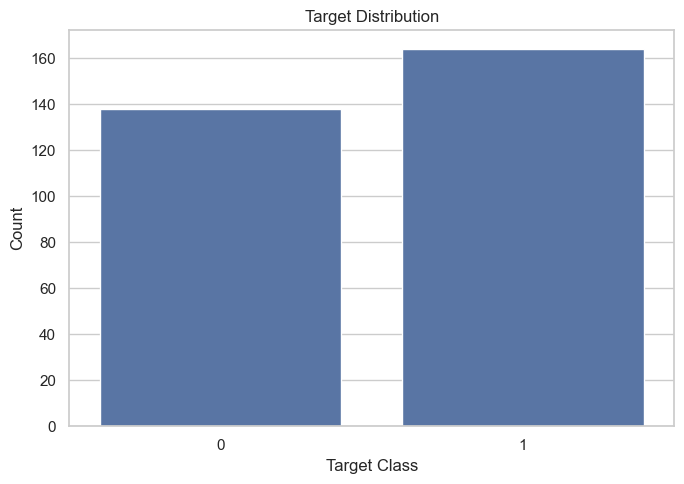

In [26]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x=TARGET_COLUMN)
plt.title("Target Distribution")
plt.xlabel("Target Class")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "heart_final_target_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


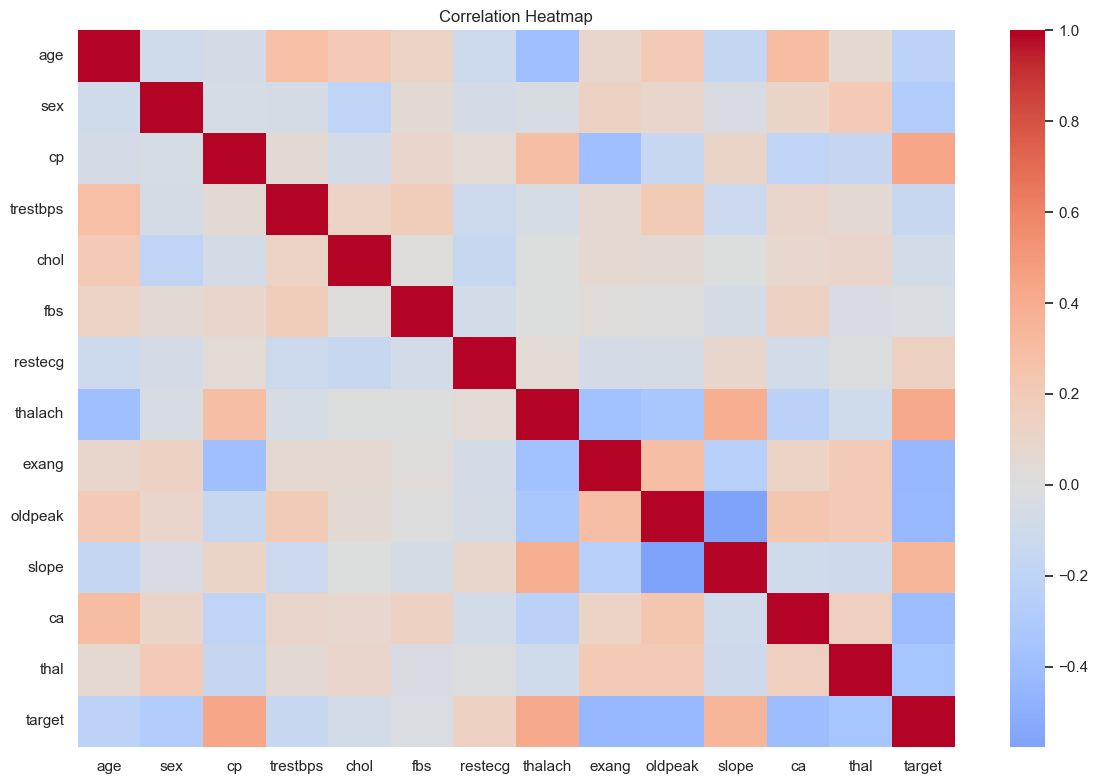

In [27]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "heart_final_correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()


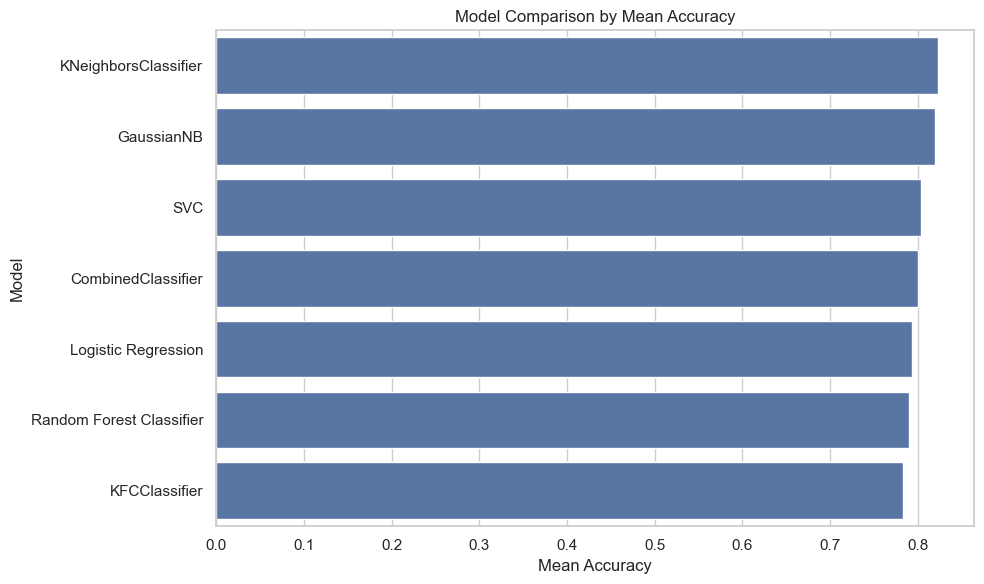

In [28]:
comparison_plot_data = aggregated_results_table.reset_index()
comparison_plot_data.columns = [
    " ".join(col).strip() if isinstance(col, tuple) else col
    for col in comparison_plot_data.columns
]

plt.figure(figsize=(10, 6))
sns.barplot(
    data=comparison_plot_data,
    x="Accuracy mean",
    y="Model",
    orient="h",
)
plt.title("Model Comparison by Mean Accuracy")
plt.xlabel("Mean Accuracy")
plt.ylabel("Model")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "heart_model_comparison_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()


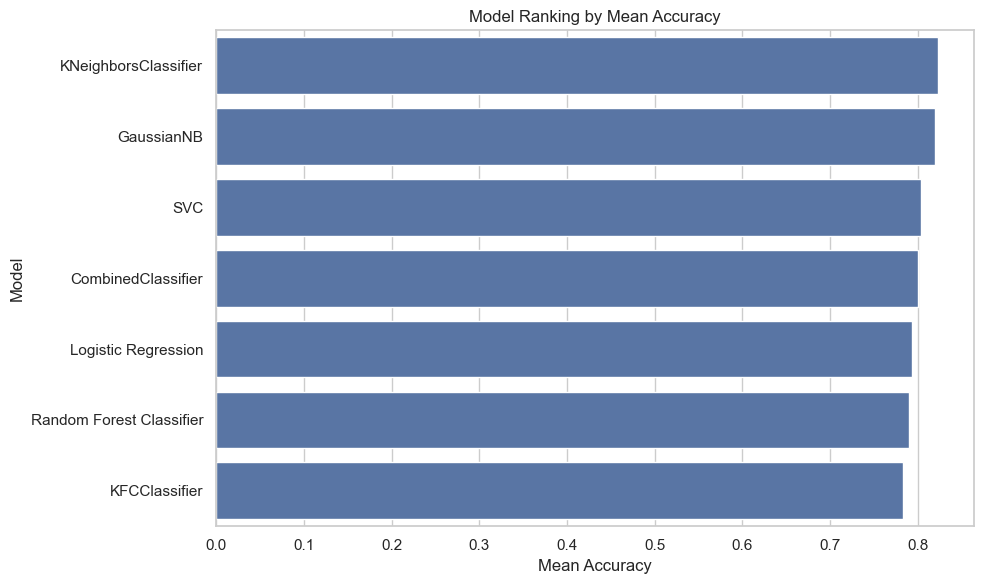

In [29]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=ranking_table,
    x=f"Mean {PRIMARY_METRIC}",
    y="Model",
    orient="h",
)
plt.title("Model Ranking by Mean Accuracy")
plt.xlabel("Mean Accuracy")
plt.ylabel("Model")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "heart_model_ranking.png", dpi=300, bbox_inches="tight")
plt.show()


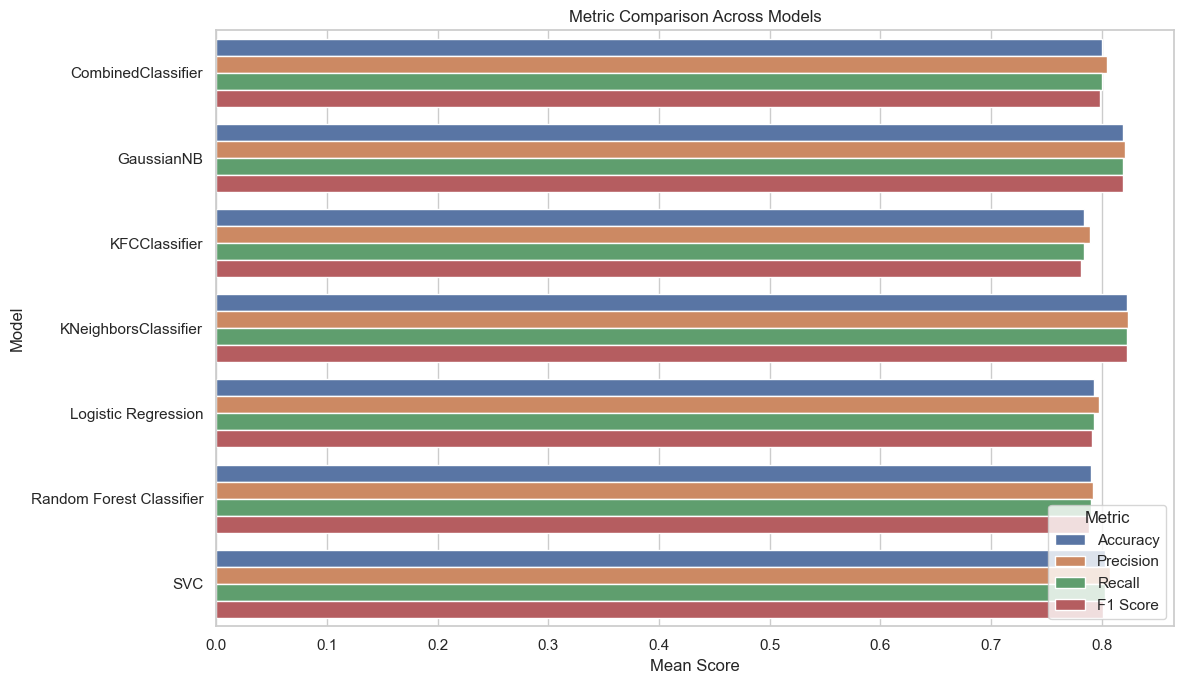

In [30]:
aggregated_mean_only = (
    successful_results
    .groupby("Model")[metric_columns]
    .mean()
    .reset_index()
)

metric_comparison_long = aggregated_mean_only.melt(
    id_vars="Model",
    value_vars=metric_columns,
    var_name="Metric",
    value_name="Mean Score",
)

plt.figure(figsize=(12, 7))
sns.barplot(
    data=metric_comparison_long,
    x="Mean Score",
    y="Model",
    hue="Metric",
    orient="h",
)
plt.title("Metric Comparison Across Models")
plt.xlabel("Mean Score")
plt.ylabel("Model")
plt.legend(title="Metric", loc="lower right")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "heart_metric_comparison.png", dpi=300, bbox_inches="tight")
plt.show()


## 15. LaTeX-Ready Tables

The following cells generate LaTeX-ready tables for thesis writing.

The tables are generated from the computed experiment results. No values are manually inserted.


In [31]:
latex_per_seed_table = per_seed_results_table.drop(columns=["Error Message"]).to_latex(
    index=False,
    float_format="%.4f",
    caption="Per-seed Heart Disease classification results.",
    label="tab:heart_per_seed_results",
)

print(latex_per_seed_table)

with open(TABLE_DIR / "heart_per_seed_results.tex", "w", encoding="utf-8") as f:
    f.write(latex_per_seed_table)


\begin{table}
\caption{Per-seed Heart Disease classification results.}
\label{tab:heart_per_seed_results}
\begin{tabular}{lrrrrrrrl}
\toprule
Model & Seed & Accuracy & Precision & Recall & F1 Score & Fit Time & Prediction Time & Status \\
\midrule
CombinedClassifier & 42 & 0.7541 & 0.7537 & 0.7541 & 0.7537 & 0.5636 & 0.0064 & success \\
GaussianNB & 42 & 0.7869 & 0.7914 & 0.7869 & 0.7872 & 0.0003 & 0.0001 & success \\
KFCClassifier & 42 & 0.7705 & 0.7729 & 0.7705 & 0.7709 & 0.4056 & 0.0017 & success \\
KNeighborsClassifier & 42 & 0.7869 & 0.7878 & 0.7869 & 0.7871 & 0.0003 & 0.0010 & success \\
Logistic Regression & 42 & 0.7869 & 0.7880 & 0.7869 & 0.7855 & 0.0014 & 0.0001 & success \\
Random Forest Classifier & 42 & 0.7377 & 0.7373 & 0.7377 & 0.7367 & 0.0404 & 0.0024 & success \\
SVC & 42 & 0.7541 & 0.7537 & 0.7541 & 0.7537 & 0.0026 & 0.0003 & success \\
CombinedClassifier & 52 & 0.8525 & 0.8699 & 0.8525 & 0.8490 & 0.2767 & 0.0047 & success \\
GaussianNB & 52 & 0.8525 & 0.8548 & 0.8525 

In [32]:
latex_aggregated_table = formatted_aggregated_results.to_latex(
    index=False,
    escape=False,
    caption="Aggregated Heart Disease classification results across five random seeds.",
    label="tab:heart_aggregated_results",
)

print(latex_aggregated_table)

with open(TABLE_DIR / "heart_aggregated_results.tex", "w", encoding="utf-8") as f:
    f.write(latex_aggregated_table)


\begin{table}
\caption{Aggregated Heart Disease classification results across five random seeds.}
\label{tab:heart_aggregated_results}
\begin{tabular}{lllll}
\toprule
Model & Accuracy & Precision & Recall & F1 Score \\
\midrule
KNeighborsClassifier & 0.823 ± 0.052 & 0.824 ± 0.051 & 0.823 ± 0.052 & 0.823 ± 0.052 \\
GaussianNB & 0.820 ± 0.038 & 0.821 ± 0.039 & 0.820 ± 0.038 & 0.819 ± 0.038 \\
SVC & 0.803 ± 0.037 & 0.808 ± 0.040 & 0.803 ± 0.037 & 0.801 ± 0.036 \\
CombinedClassifier & 0.800 ± 0.068 & 0.805 ± 0.075 & 0.800 ± 0.068 & 0.799 ± 0.067 \\
Logistic Regression & 0.793 ± 0.034 & 0.798 ± 0.036 & 0.793 ± 0.034 & 0.791 ± 0.034 \\
Random Forest Classifier & 0.790 ± 0.048 & 0.792 ± 0.048 & 0.790 ± 0.048 & 0.789 ± 0.049 \\
KFCClassifier & 0.784 ± 0.032 & 0.789 ± 0.037 & 0.784 ± 0.032 & 0.782 ± 0.030 \\
\bottomrule
\end{tabular}
\end{table}



In [33]:
latex_ranking_table = ranking_table.to_latex(
    index=False,
    float_format="%.4f",
    caption="Model ranking by mean accuracy for the Heart Disease classification experiment.",
    label="tab:heart_model_ranking",
)

print(latex_ranking_table)

with open(TABLE_DIR / "heart_model_ranking.tex", "w", encoding="utf-8") as f:
    f.write(latex_ranking_table)


\begin{table}
\caption{Model ranking by mean accuracy for the Heart Disease classification experiment.}
\label{tab:heart_model_ranking}
\begin{tabular}{rlr}
\toprule
Rank & Model & Mean Accuracy \\
\midrule
1 & KNeighborsClassifier & 0.8230 \\
2 & GaussianNB & 0.8197 \\
3 & SVC & 0.8033 \\
4 & CombinedClassifier & 0.8000 \\
5 & Logistic Regression & 0.7934 \\
6 & Random Forest Classifier & 0.7902 \\
7 & KFCClassifier & 0.7836 \\
\bottomrule
\end{tabular}
\end{table}



## 16. Discussion

### Comparison of Baselines

The baseline models provide a reference for evaluating whether the more complex aggregation-based methods improve classification performance. The comparison should be based on the aggregated results table rather than a single train-test split.

The best baseline model can be identified by ranking the baseline classifiers according to mean accuracy and F1-score.

### Comparison of COBRA Models

The classification-appropriate COBRA model used in this experiment is `CombinedClassifier`.

`GradientCOBRA` and `MixCOBRARegressor` are excluded because they are regression-oriented and not appropriate for the Heart Disease classification task.

The performance of `CombinedClassifier` should be compared against both individual baseline classifiers and `KFCClassifier`.

### Comparison of KFC Models

The KFCProcedure experiment is represented by `KFCClassifier`.

The KFC pipeline applies:

- K-Step: divergence-based clustering
- F-Step: cluster-wise local logistic regression
- C-Step: COBRA-based aggregation using `combined_classifier`

The resulting performance should be interpreted relative to the baselines and the standalone COBRA classifier.

### Strengths

The experiment has the following strengths:

1. It uses repeated evaluation across five random seeds.
2. All models are evaluated using the same train-test split for each seed.
3. Scaling is performed inside each seed-specific split to avoid data leakage.
4. The same classification metrics are used for all models.
5. Results are reported using mean and standard deviation.
6. Per-seed results are retained to support auditability.

### Limitations

The experiment has the following limitations:

1. The dataset is relatively small after duplicate removal.
2. The experiment uses repeated train-test splits rather than nested cross-validation.
3. Hyperparameter tuning beyond repository-supported model configuration is not introduced.
4. Outlier handling is not applied because it is not observable from the provided materials.
5. Feature selection is not applied because it is not observable from the provided materials.
6. KFCProcedure may be sensitive to cluster composition because local classifiers require valid class distributions inside clusters.

### Threats to Validity

Potential threats to validity include:

1. Model rankings may change under different hyperparameter settings.
2. Performance may vary with alternative preprocessing choices.
3. Duplicate records existed before cleaning, making duplicate removal necessary.
4. The results are specific to the selected Heart Disease dataset and may not generalize to other clinical datasets.
5. Complex aggregation models may be less interpretable than simpler baseline classifiers.


In [34]:
baseline_model_names = [
    "Logistic Regression",
    "Random Forest Classifier",
    "SVC",
    "KNeighborsClassifier",
    "GaussianNB",
]

baseline_ranking = ranking_table[
    ranking_table["Model"].isin(baseline_model_names)
].reset_index(drop=True)

cobra_result = ranking_table[
    ranking_table["Model"] == "CombinedClassifier"
]

kfc_result = ranking_table[
    ranking_table["Model"] == "KFCClassifier"
]

print("Baseline ranking:")
display(baseline_ranking)

print("COBRA result:")
display(cobra_result)

print("KFC result:")
display(kfc_result)


Baseline ranking:


,Rank,Model,Mean Accuracy
0,1,KNeighborsClassifier,0.822951
1,2,GaussianNB,0.819672
2,3,SVC,0.803279
3,5,Logistic Regression,0.793443
4,6,Random Forest Classifier,0.790164


COBRA result:


,Rank,Model,Mean Accuracy
3,4,CombinedClassifier,0.8


KFC result:


,Rank,Model,Mean Accuracy
6,7,KFCClassifier,0.783607


## 17. Conclusion

This notebook implemented a complete Heart Disease classification experiment for the thesis project:

**kfc-procedure: A Unified Framework for Clusterwise Learning and COBRA-Based Ensemble Aggregation**

The experiment evaluated:

1. Baseline machine learning classifiers
2. `CombinedClassifier`
3. `KFCClassifier`

The experimental design emphasized reproducibility and statistical reporting by using five repeated train-test splits with the seeds:

```python
[42, 52, 62, 72, 82]
```

For each seed, the dataset was split, scaled, trained, predicted, and evaluated independently. The final results were summarized using mean and standard deviation for Accuracy, Precision, Recall, and F1-score.

The final interpretation should be based on the generated aggregated results table and ranking table. No performance claim should be made without referring to the computed values in those tables.


## 18. Reproducibility Checklist

The following checklist summarizes the reproducibility controls used in this notebook:

- Dataset source is explicitly stated.
- Duplicate removal is performed before modeling.
- Target column is explicitly defined.
- Random seeds are explicitly defined.
- Train-test split is stratified by the target variable.
- Scaling is fitted only on the training split.
- Every model is evaluated on the same test split for each seed.
- Evaluation metrics are fixed and consistently applied.
- Per-seed results are stored.
- Aggregated mean and standard deviation are computed.
- LaTeX-ready tables are generated from computed results.
- Figures and tables are saved under the `outputs/` directory.
